Epoch 0/19
----------
train Loss: 0.2985 Acc: 0.8743
val Loss: 0.0542 Acc: 0.9950

Epoch 1/19
----------
train Loss: 0.1766 Acc: 0.9306
val Loss: 0.0214 Acc: 0.9950

Epoch 2/19
----------
train Loss: 0.1694 Acc: 0.9353
val Loss: 0.0403 Acc: 0.9950

Epoch 3/19
----------
train Loss: 0.1291 Acc: 0.9550
val Loss: 0.0309 Acc: 0.9900

Epoch 4/19
----------
train Loss: 0.0841 Acc: 0.9756
val Loss: 0.0114 Acc: 1.0000

Epoch 5/19
----------
train Loss: 0.0831 Acc: 0.9709
val Loss: 0.0122 Acc: 0.9950

Epoch 6/19
----------
train Loss: 0.0677 Acc: 0.9803
val Loss: 0.0163 Acc: 1.0000

Epoch 7/19
----------
train Loss: 0.0717 Acc: 0.9831
val Loss: 0.0131 Acc: 0.9950

Epoch 8/19
----------
train Loss: 0.0516 Acc: 0.9841
val Loss: 0.0115 Acc: 0.9950

Epoch 9/19
----------
train Loss: 0.0477 Acc: 0.9841
val Loss: 0.0090 Acc: 1.0000

Epoch 10/19
----------
train Loss: 0.0512 Acc: 0.9841
val Loss: 0.0151 Acc: 0.9950

Epoch 11/19
----------
train Loss: 0.0424 Acc: 0.9859
val Loss: 0.0160 Acc: 0.9950

Ep

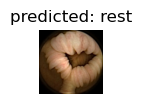

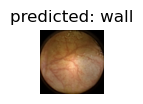

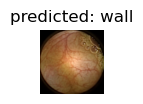

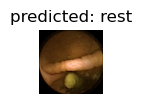

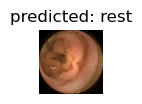

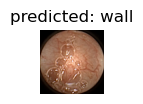

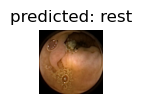

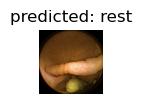

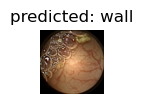

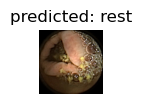

Test Loss: 0.0176 Test Acc: 1.0000


In [5]:
import os
import random
from PIL import Image
import glob
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import time
from tempfile import TemporaryDirectory
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np

save_model_path = r"C:\Users\psh006\OneDrive - UiT Office 365\ML codes\AICE\models\model.pth"

def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                   

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path))
    return model

# Visualize the model for a few images
def visualize_model(model, num_images=10):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)



# Data augmentation and normalization for training
# Only normalization for validation and testing data
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip 50% chance
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(224),
        #transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),  
    'test': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}



data_dir = r"C:\Users\psh006\OneDrive - UiT Office 365\ML codes\AICE\DataSet"
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val', 'test']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=8,
                                             shuffle=True)
              for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes


model_ft = models.resnet50(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to len of Classes.
model_ft.fc = nn.Linear(num_ftrs, len(class_names))


criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 8 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=8, gamma=0.1)

model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=20)


# Save model
torch.save(model_ft.state_dict(),save_model_path)

visualize_model(model_ft)

model_ft.eval()

running_loss = 0.0
running_corrects = 0

with torch.no_grad():
    for i, (inputs, labels) in enumerate(dataloaders['test']):
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        test_loss = criterion(outputs, labels)        
        # statistics
        running_loss += test_loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        

test_loss = running_loss / dataset_sizes['test']
test_acc = running_corrects.double() / dataset_sizes['test']
        
print(f'Test Loss: {test_loss:.4f} Test Acc: {test_acc:.4f}')
